In [1]:
import glob
from PIL import Image, ImageDraw, ImageFont
from skimage.filters import threshold_otsu
from scipy import ndimage
from matplotlib import pyplot as plt
import numpy as np

In [2]:
path =r"E:\Studies\TU Darmstadt\Wise 2019\ARL\Raw data\March 16 SEM VSM\Naga SEM data\FeRhPdIr\FM07867 FeRhPdIr0.009 after HT 1000\FM07867 FeRhPdIr0.009 plate after HT 1000\*.tif"#Enter file path in xxxx portion
magnification = 2000#enter the magnification manually

In [3]:
"""Smoothing and thresholding"""
def phase_quantification(img):
    img_array = np.array(img)
    img_median_filter = ndimage.median_filter(img_array,size=3)#Variables for smoothening
    img_gaussian_filter = ndimage.gaussian_filter(img_median_filter,sigma=0.4)#Variables for smoothening
    print (img_gaussian_filter.shape)
    threshold_value = threshold_otsu(img_gaussian_filter)
    img_otsu_gaussian = img_gaussian_filter >= threshold_value
    phase_fraction = np.sum(img_otsu_gaussian==1)*100/(np.sum(img_otsu_gaussian==0)+np.sum(img_otsu_gaussian==1))
    return(img_otsu_gaussian,phase_fraction)


"""Scale"""

def scale_calibration(magnification,path):
    scale = (0.1351351351*160*2000)/magnification##only for TescanVEGA3 pictures#160-pixel length--> this can be changed to modify the length of the scale
    if (scale%10<=5):
        scale = scale-(scale%10)
    else:
        scale = scale-(scale%10)+10
    scale = int(scale)
    pixel_len = (scale*magnification)/(2000*0.1351351351)
    scale_img =plt.imread(path)
    scale_img = scale_img[0:768,0:1024]
    scale_img = (scale_img/256)#.astype('uint8')
    plt.imsave(path+"_scaled.png",scale_img,format ='png',cmap='gray')
    scale_img = Image.open(path+"_scaled.png")
    draw = ImageDraw.Draw(scale_img)
    font1 = ImageFont.truetype("arial.ttf",36)
    string = str(scale)+' \u03BCm'
    draw.text((840,680),string,"white",font =font1)
    draw.line((972-pixel_len,666,972,666),"white",width=10)   
    scale_img.save(file+"_scaled.png",format ='png',cmap='gray')

In [4]:
"""Import and save file"""
phase_percent =[]

for file in glob.glob(path):
    img = Image.open(file)
    crop_img = img.crop((0,0,1024,768))##(x1,y1,x2,y2)
    binary_img, phase_fractemp = phase_quantification(crop_img)
    phase_percent.append(phase_fractemp)
    plt.imsave(file+"_binary.tiff",binary_img,cmap='gray')
    scale_calibration(magnification,file)
    
phase_percentage = np.sum(phase_percent)/np.count_nonzero(phase_percent)
print("The phase percentage is", phase_percentage)

(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
The phase percentage is 22.887039184570312


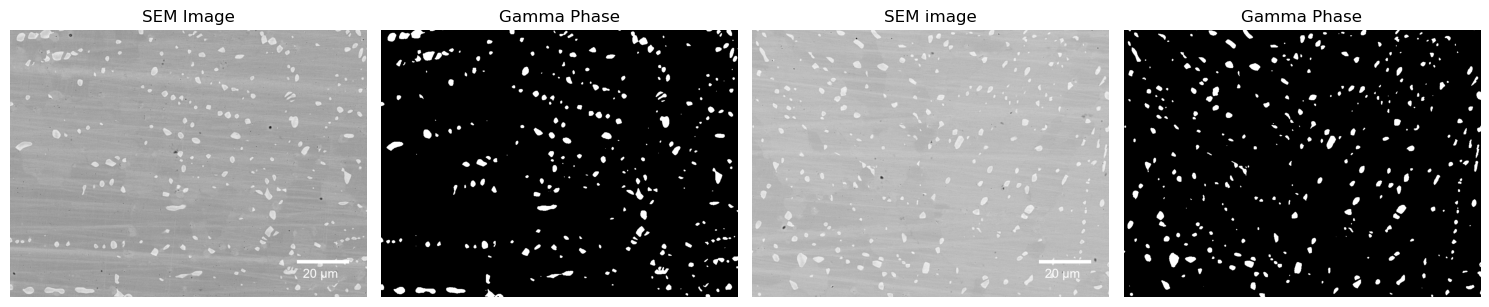

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

files = ["FM07868 FeRhPdIr0.009 after HT 850-plate-BSE-1500x-1.tif_scaled.png", "FM07868 FeRhPdIr0.009 after HT 850-plate-BSE-1500x-1.tif_binary.tiff",
         "FM07868 FeRhPdIr0.009 after HT 850-plate-BSE-1500x-3.tif_scaled.png","FM07868 FeRhPdIr0.009 after HT 850-plate-BSE-1500x-3.tif_binary.tiff"]
titles = [
    "SEM Image",
    "Gamma Phase",
    "SEM image",
    "Gamma Phase",
]

fig, axes = plt.subplots(1, len(files), figsize=(15, 5))

for ax, file, title in zip(axes, files, titles):
    img = Image.open(file)
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()